In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"]     = 100
sns.set_theme(style="darkgrid")

os.makedirs("bluestock/reports/charts", exist_ok=True)

print("Libraries imported")

Libraries imported


In [2]:
PROC = "bluestock/data/processed"

df_nav   = pd.read_csv(f"{PROC}/02_nav_history_clean.csv",
                        parse_dates=["date"])
df_fund  = pd.read_csv(f"{PROC}/01_fund_master_clean.csv")
df_txn   = pd.read_csv(f"{PROC}/08_transactions_clean.csv",
                        parse_dates=["transaction_date"])
df_hold  = pd.read_csv(f"{PROC}/09_holdings_clean.csv")
df_score = pd.read_csv(f"{PROC}/fund_scorecard.csv")
df_master= pd.read_csv(f"{PROC}/performance_master.csv")

print("All data loaded")
print(f"   NAV records   : {len(df_nav):,}")
print(f"   Transactions  : {len(df_txn):,}")
print(f"   Investors     : {df_txn['investor_id'].nunique():,}")

All data loaded
   NAV records   : 46,000
   Transactions  : 32,778
   Investors     : 5,000


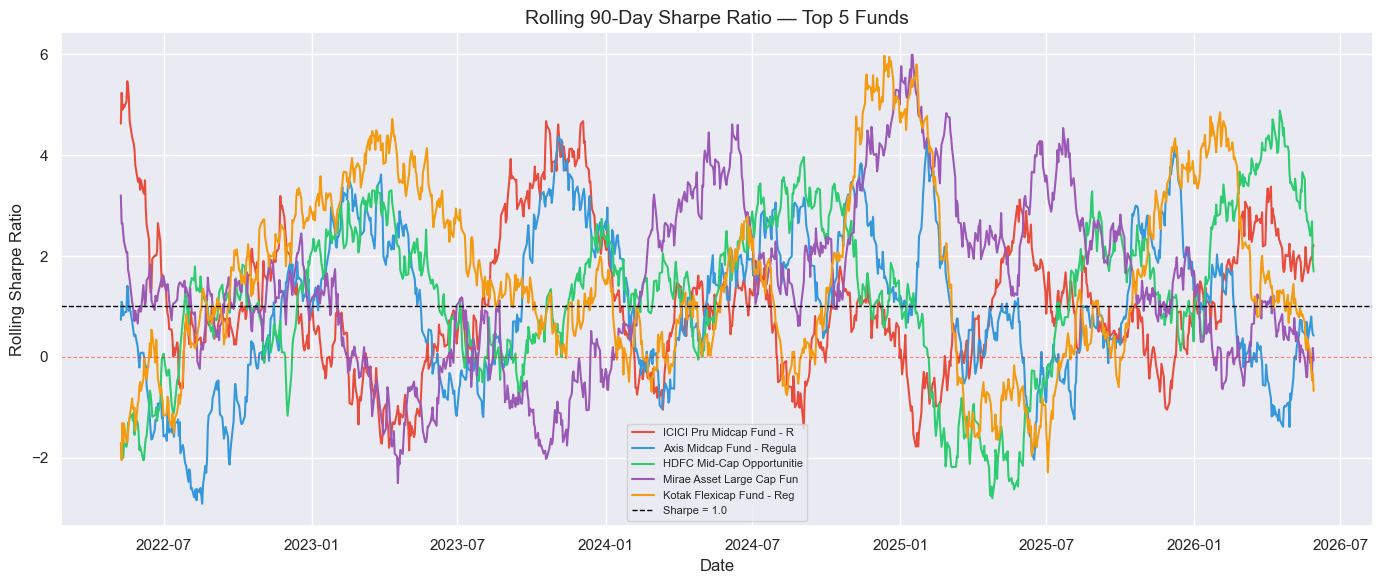

Rolling Sharpe chart saved


In [3]:
RISK_FREE_DAILY = 0.065 / 252

# Pick top 5 funds by composite score
top5 = df_score.head(5)[["amfi_code","scheme_name"]].copy()
top5["label"] = top5["scheme_name"].str[:25]

fig, ax = plt.subplots(figsize=(14, 6))

colors = ["#e74c3c","#3498db","#2ecc71","#9b59b6","#f39c12"]

for (_, row), color in zip(top5.iterrows(), colors):
    grp = df_nav[df_nav["amfi_code"] == row["amfi_code"]]\
              .sort_values("date").copy()

    grp["daily_ret"] = grp["nav"].pct_change()
    grp["excess"]    = grp["daily_ret"] - RISK_FREE_DAILY

    # Rolling Sharpe
    grp["rolling_sharpe"] = (
        grp["excess"].rolling(90).mean() /
        grp["daily_ret"].rolling(90).std()
    ) * np.sqrt(252)

    ax.plot(grp["date"], grp["rolling_sharpe"],
            label=row["label"], linewidth=1.5, color=color)

ax.axhline(y=1.0, color="black", linestyle="--",
           linewidth=1, label="Sharpe = 1.0")
ax.axhline(y=0.0, color="red",   linestyle="--",
           linewidth=0.8, alpha=0.5)
ax.set_title("Rolling 90-Day Sharpe Ratio — Top 5 Funds", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe Ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("bluestock/reports/charts/rolling_sharpe.png", dpi=150)
plt.show()
print("Rolling Sharpe chart saved")

 Cohort Analysis:
 cohort_year  num_investors  total_invested  avg_sip_amount  num_transactions  avg_txn_per_investor
        2024           4803      3491125187   107422.541832             32499                   6.8
        2025            197        30455243   109158.577061               279                   1.4


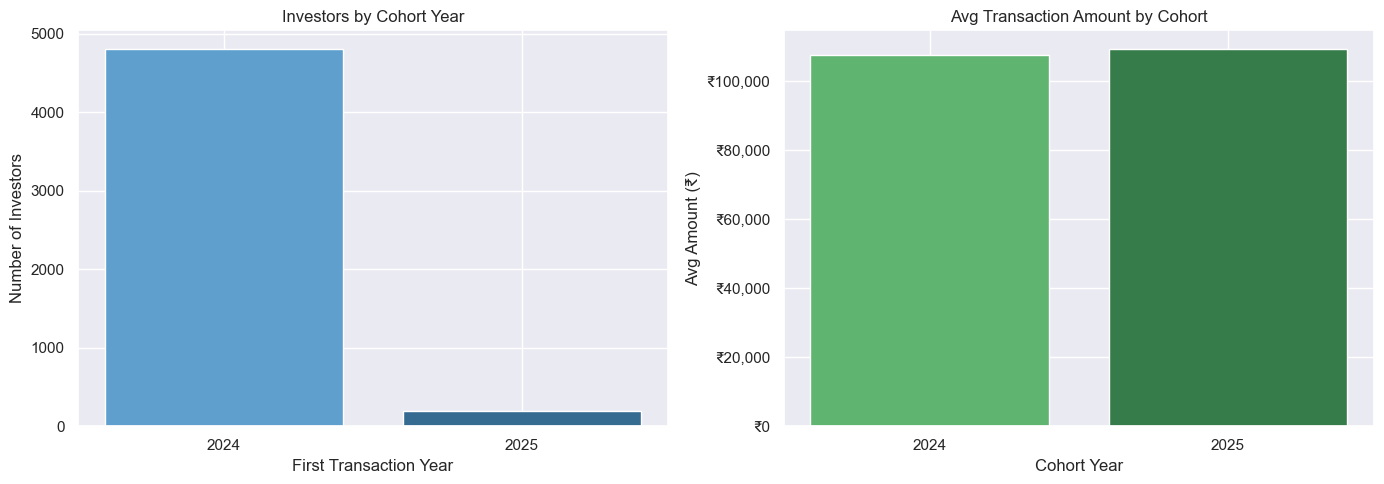

 Cohort chart saved


In [4]:
# Group investors by first transaction year
first_txn = df_txn.groupby("investor_id")["transaction_date"].min().reset_index()
first_txn.columns = ["investor_id","first_txn_date"]
first_txn["cohort_year"] = first_txn["first_txn_date"].dt.year

# Merge back
df_cohort = df_txn.merge(first_txn[["investor_id","cohort_year"]],
                          on="investor_id")

# Cohort stats
cohort_stats = df_cohort.groupby("cohort_year").agg(
    num_investors    = ("investor_id",    "nunique"),
    total_invested   = ("amount_inr",     "sum"),
    avg_sip_amount   = ("amount_inr",     "mean"),
    num_transactions = ("investor_id",    "count"),
).reset_index()

cohort_stats["avg_txn_per_investor"] = (
    cohort_stats["num_transactions"] /
    cohort_stats["num_investors"]
).round(1)

cohort_stats.to_csv(f"{PROC}/cohort_analysis.csv", index=False)

print(" Cohort Analysis:")
print(cohort_stats.to_string(index=False))

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cohort_stats["cohort_year"].astype(str),
            cohort_stats["num_investors"],
            color=sns.color_palette("Blues_d", len(cohort_stats)))
axes[0].set_title("Investors by Cohort Year")
axes[0].set_xlabel("First Transaction Year")
axes[0].set_ylabel("Number of Investors")

axes[1].bar(cohort_stats["cohort_year"].astype(str),
            cohort_stats["avg_sip_amount"],
            color=sns.color_palette("Greens_d", len(cohort_stats)))
axes[1].set_title("Avg Transaction Amount by Cohort")
axes[1].set_xlabel("Cohort Year")
axes[1].set_ylabel("Avg Amount (₹)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f"₹{x:,.0f}"))

plt.tight_layout()
plt.savefig("bluestock/reports/charts/cohort_analysis.png", dpi=150)
plt.show()
print(" Cohort chart saved")

 SIP Continuity Analysis:
   Total regular investors  : 1,362
   At Risk (gap > 35 days)  : 1,332
   Regular investors        : 30


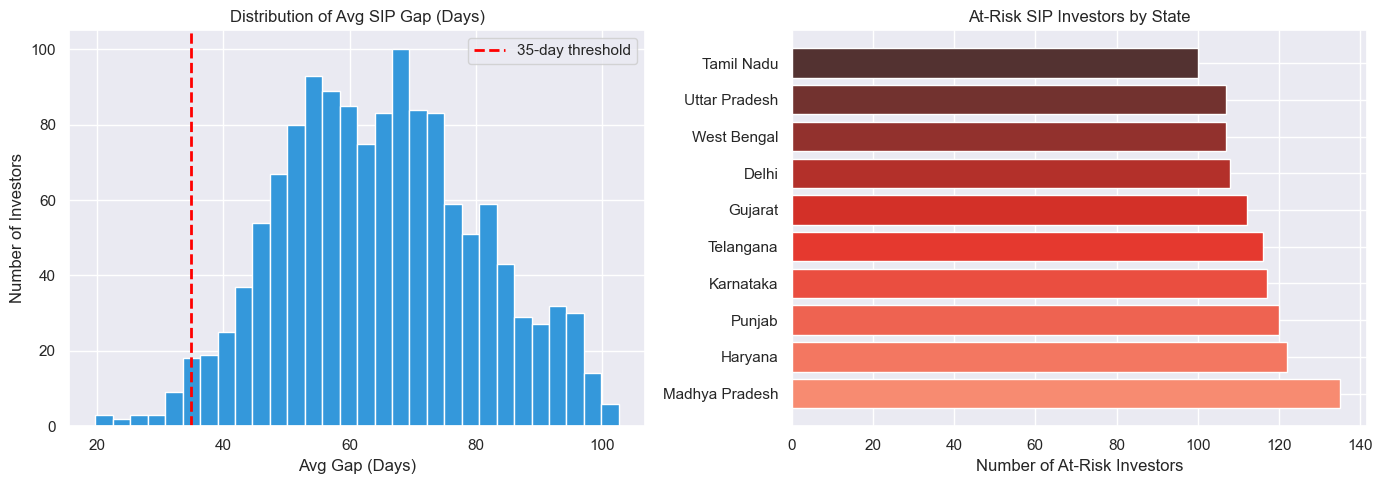

 SIP Continuity chart saved


In [5]:
# Only SIP transactions
df_sip_only = df_txn[df_txn["transaction_type"] == "Sip"].copy()
df_sip_only = df_sip_only.sort_values(["investor_id","transaction_date"])

# Gap between SIP transactions per investor
df_sip_only["prev_date"] = df_sip_only.groupby(
    "investor_id")["transaction_date"].shift(1)
df_sip_only["gap_days"]  = (
    df_sip_only["transaction_date"] -
    df_sip_only["prev_date"]
).dt.days

# Investors with 6+ SIP transactions
sip_counts = df_sip_only.groupby("investor_id").size()
regular_investors = sip_counts[sip_counts >= 6].index

df_regular = df_sip_only[
    df_sip_only["investor_id"].isin(regular_investors)
].copy()

# Average gap per investor
investor_gaps = df_regular.groupby("investor_id")["gap_days"].mean().reset_index()
investor_gaps.columns = ["investor_id","avg_gap_days"]

# Flag at-risk (gap > 35 days)
investor_gaps["status"] = investor_gaps["avg_gap_days"].apply(
    lambda x: "At Risk " if x > 35 else "Regular "
)

# Merge with investor info
investor_gaps = investor_gaps.merge(
    df_txn[["investor_id","state","age_group",
            "city_tier"]].drop_duplicates("investor_id"),
    on="investor_id"
)

investor_gaps.to_csv(f"{PROC}/sip_continuity.csv", index=False)

print(" SIP Continuity Analysis:")
print(f"   Total regular investors  : {len(investor_gaps):,}")
print(f"   At Risk (gap > 35 days)  : {(investor_gaps['status']=='At Risk ').sum():,}")
print(f"   Regular investors        : {(investor_gaps['status']=='Regular ').sum():,}")

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gap distribution
axes[0].hist(investor_gaps["avg_gap_days"].dropna(),
             bins=30, color="#3498db", edgecolor="white")
axes[0].axvline(x=35, color="red", linestyle="--",
                linewidth=2, label="35-day threshold")
axes[0].set_title("Distribution of Avg SIP Gap (Days)")
axes[0].set_xlabel("Avg Gap (Days)")
axes[0].set_ylabel("Number of Investors")
axes[0].legend()

# At-risk by state
risk_state = investor_gaps[
    investor_gaps["status"] == "At Risk "
]["state"].value_counts().head(10)
axes[1].barh(risk_state.index, risk_state.values,
             color=sns.color_palette("Reds_d", len(risk_state)))
axes[1].set_title("At-Risk SIP Investors by State")
axes[1].set_xlabel("Number of At-Risk Investors")

plt.tight_layout()
plt.savefig("bluestock/reports/charts/sip_continuity.png", dpi=150)
plt.show()
print(" SIP Continuity chart saved")

In [7]:
def recommend_funds(risk_appetite: str, top_n: int = 3) -> pd.DataFrame:
    risk_map = {
        "Low"       : ["Low"],
        "Moderate"  : ["Moderate","Low"],
        "High"      : ["High","Moderately High","Moderate"],
        "Very High" : ["Very High","High","Moderately High"],
    }

    allowed = risk_map.get(risk_appetite, ["Moderate"])

    filtered = df_score[
        df_score["amfi_code"].isin(
            df_fund[df_fund["risk_category"].isin(allowed)]["amfi_code"]
        )
    ].copy()

    # ── Only merge columns NOT already in df_score ──────────
    filtered = filtered.merge(
        df_fund[["amfi_code","risk_category","fund_manager","sub_category"]],
        on="amfi_code", how="left"
    )

    # ── Select only columns that exist ───────────────────────
    cols = ["scheme_name","fund_house","sub_category",
            "sharpe_ratio","cagr_3y_pct","composite_score",
            "risk_category","fund_manager"]

    # Add expense_ratio_pct only if it exists
    if "expense_ratio_pct" in filtered.columns:
        cols.append("expense_ratio_pct")

    top = filtered.nlargest(top_n, "sharpe_ratio")[cols]
    return top


# Test all risk levels
print("="*65)
print("  FUND RECOMMENDER SYSTEM")
print("="*65)

for risk in ["Low","Moderate","High","Very High"]:
    print(f"\n Risk Appetite : {risk}")
    print("-"*65)
    result = recommend_funds(risk, top_n=3)
    for _, row in result.iterrows():
        print(f"   {row['scheme_name'][:40]}")
        print(f"     Sharpe : {row['sharpe_ratio']:.3f} | "
              f"3Y CAGR : {row['cagr_3y_pct']:.2f}% | "
              f"Score   : {row['composite_score']:.1f}")

# Save recommender script
recommender_code = '''
import pandas as pd

def recommend_funds(risk_appetite, df_score, df_fund, top_n=3):
    risk_map = {
        "Low"       : ["Low"],
        "Moderate"  : ["Moderate","Low"],
        "High"      : ["High","Moderately High","Moderate"],
        "Very High" : ["Very High","High","Moderately High"],
    }
    allowed  = risk_map.get(risk_appetite, ["Moderate"])
    filtered = df_score[df_score["amfi_code"].isin(
        df_fund[df_fund["risk_category"].isin(allowed)]["amfi_code"]
    )].copy()
    filtered = filtered.merge(
        df_fund[["amfi_code","risk_category","fund_manager","sub_category"]],
        on="amfi_code", how="left")
    cols = ["scheme_name","fund_house","sub_category",
            "sharpe_ratio","cagr_3y_pct","composite_score",
            "risk_category","fund_manager"]
    if "expense_ratio_pct" in filtered.columns:
        cols.append("expense_ratio_pct")
    return filtered.nlargest(top_n, "sharpe_ratio")[cols]

if __name__ == "__main__":
    PROC     = "bluestock/data/processed"
    df_score = pd.read_csv(f"{PROC}/fund_scorecard.csv")
    df_fund  = pd.read_csv(f"{PROC}/01_fund_master_clean.csv")
    risk     = input("Enter risk appetite (Low/Moderate/High/Very High): ")
    print(recommend_funds(risk, df_score, df_fund).to_string(index=False))
'''

os.makedirs("bluestock/scripts", exist_ok=True)
with open("bluestock/scripts/recommender.py", "w") as f:
    f.write(recommender_code)

print("\n recommender.py saved")

  FUND RECOMMENDER SYSTEM

 Risk Appetite : Low
-----------------------------------------------------------------
   ICICI Pru Liquid Fund - Regular - Growth
     Sharpe : 0.496 | 3Y CAGR : 7.39% | Score   : 38.2
   Kotak Liquid Fund - Regular - Growth
     Sharpe : -0.089 | 3Y CAGR : 6.70% | Score   : 31.9
   SBI Magnum Gilt Fund - Regular Plan - Gr
     Sharpe : -0.227 | 3Y CAGR : 5.84% | Score   : 26.0

 Risk Appetite : Moderate
-----------------------------------------------------------------
   Mirae Asset Large Cap Fund - Regular - G
     Sharpe : 1.448 | 3Y CAGR : 34.00% | Score   : 80.0
   SBI Bluechip Fund - Regular Plan - Growt
     Sharpe : 1.208 | 3Y CAGR : 30.46% | Score   : 73.1
   Nippon India Large Cap Fund - Regular - 
     Sharpe : 1.082 | 3Y CAGR : 22.65% | Score   : 67.8

 Risk Appetite : High
-----------------------------------------------------------------
   Mirae Asset Large Cap Fund - Regular - G
     Sharpe : 1.448 | 3Y CAGR : 34.00% | Score   : 80.0
   Kotak 

 Sector HHI computed:
                                          scheme_name  stock_hhi  sector_hhi concentration
            HDFC Top 100 Fund - Regular Plan - Growth     0.1395      0.1806     Moderate 
   HDFC Mid-Cap Opportunities Fund - Regular - Growth     0.1476      0.2276     Moderate 
        ABSL Frontline Equity Fund - Regular - Growth     0.1293      0.1800     Moderate 
               ABSL Small Cap Fund - Regular - Growth     0.2007      0.2228     Moderate 
           UTI Nifty 50 Index Fund - Regular - Growth     0.1747      0.1807     Moderate 
                  UTI Mid Cap Fund - Regular - Growth     0.1147      0.1241          Low 
                UTI Flexi Cap Fund - Regular - Growth     0.1298      0.2513     Moderate 
       Nippon India Large Cap Fund - Regular - Growth     0.1682      0.2072     Moderate 
        Nippon India Large Cap Fund - Direct - Growth     0.1215      0.2212     Moderate 
       Nippon India Small Cap Fund - Regular - Growth     0.1084    

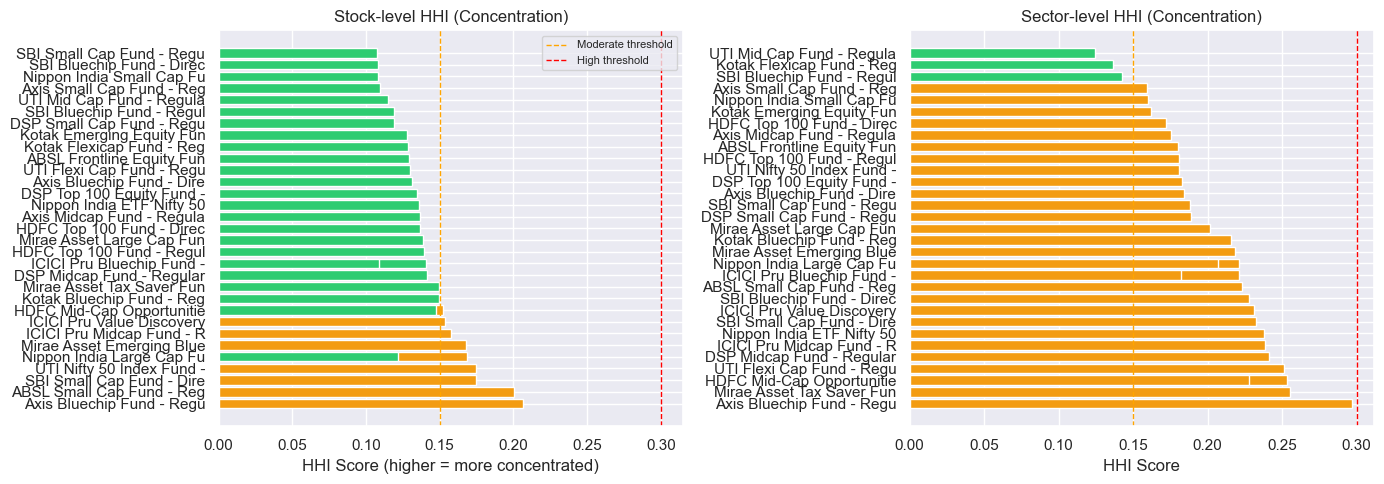

 HHI chart saved


In [8]:
# HHI = sum of squared weights per fund
# High HHI = concentrated | Low HHI = diversified

hhi_rows = []

for code, grp in df_hold.groupby("amfi_code"):
    # Normalize weights
    total_wt = grp["weight_pct"].sum()
    weights  = grp["weight_pct"] / total_wt

    # Stock-level HHI
    stock_hhi  = (weights ** 2).sum()

    # Sector-level HHI
    sector_wt  = grp.groupby("sector")["weight_pct"].sum() / total_wt
    sector_hhi = (sector_wt ** 2).sum()

    hhi_rows.append({
        "amfi_code"  : code,
        "stock_hhi"  : round(stock_hhi,  4),
        "sector_hhi" : round(sector_hhi, 4),
    })

df_hhi = pd.DataFrame(hhi_rows)
df_hhi = df_hhi.merge(
    df_fund[["amfi_code","scheme_name","fund_house","sub_category"]],
    on="amfi_code")

# Label concentration
df_hhi["concentration"] = df_hhi["sector_hhi"].apply(
    lambda x: "High " if x > 0.3
              else "Moderate " if x > 0.15
              else "Low "
)

df_hhi.to_csv(f"{PROC}/sector_hhi.csv", index=False)

print(" Sector HHI computed:")
print(df_hhi[["scheme_name","stock_hhi","sector_hhi",
              "concentration"]].to_string(index=False))

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stock HHI
df_hhi_sorted = df_hhi.sort_values("stock_hhi", ascending=False)
colors = ["#e74c3c" if x > 0.3
          else "#f39c12" if x > 0.15
          else "#2ecc71"
          for x in df_hhi_sorted["stock_hhi"]]

axes[0].barh(df_hhi_sorted["scheme_name"].str[:25],
             df_hhi_sorted["stock_hhi"], color=colors)
axes[0].set_title("Stock-level HHI (Concentration)")
axes[0].set_xlabel("HHI Score (higher = more concentrated)")
axes[0].axvline(x=0.15, color="orange", linestyle="--",
                linewidth=1, label="Moderate threshold")
axes[0].axvline(x=0.30, color="red",    linestyle="--",
                linewidth=1, label="High threshold")
axes[0].legend(fontsize=8)

# Sector HHI
df_sec_sorted = df_hhi.sort_values("sector_hhi", ascending=False)
sec_colors = ["#e74c3c" if x > 0.3
              else "#f39c12" if x > 0.15
              else "#2ecc71"
              for x in df_sec_sorted["sector_hhi"]]

axes[1].barh(df_sec_sorted["scheme_name"].str[:25],
             df_sec_sorted["sector_hhi"], color=sec_colors)
axes[1].set_title("Sector-level HHI (Concentration)")
axes[1].set_xlabel("HHI Score")
axes[1].axvline(x=0.15, color="orange", linestyle="--", linewidth=1)
axes[1].axvline(x=0.30, color="red",    linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig("bluestock/reports/charts/sector_hhi.png", dpi=150)
plt.show()
print(" HHI chart saved")

In [9]:
print("="*65)
print("  ADVANCED ANALYTICS INSIGHTS — DAY 6")
print("="*65)

# 1. Highest VaR fund
df_var = pd.read_csv(f"{PROC}/var_cvar.csv")
worst_var = df_var.nsmallest(1,"var_95_pct").iloc[0]
print(f"\n1️  Highest Risk (VaR)  : {worst_var['scheme_name'][:40]}")
print(f"    VaR 95%            : {worst_var['var_95_pct']:.3f}%/day")

# 2. Most consistent SIP investors
avg_gap = investor_gaps["avg_gap_days"].mean()
print(f"\n2️  Avg SIP gap         : {avg_gap:.1f} days")
print(f"    At-risk investors  : {(investor_gaps['status']=='At Risk ⚠️').sum():,}")

# 3. Best cohort
best_cohort = cohort_stats.nlargest(1,"avg_sip_amount").iloc[0]
print(f"\n3️ Best Cohort         : {int(best_cohort['cohort_year'])}")
print(f"    Avg Amount         : ₹{best_cohort['avg_sip_amount']:,.0f}")

# 4. Most concentrated fund
most_conc = df_hhi.nlargest(1,"sector_hhi").iloc[0]
print(f"\n4️  Most Concentrated   : {most_conc['scheme_name'][:40]}")
print(f"    Sector HHI         : {most_conc['sector_hhi']:.4f}")

# 5. Most diversified fund
most_div = df_hhi.nsmallest(1,"sector_hhi").iloc[0]
print(f"\n5️  Most Diversified    : {most_div['scheme_name'][:40]}")
print(f"    Sector HHI         : {most_div['sector_hhi']:.4f}")

# 6. Top recommended fund
top_rec = recommend_funds("High", top_n=1).iloc[0]
print(f"\n6️  Top Pick (High Risk): {top_rec['scheme_name'][:40]}")
print(f"    Sharpe             : {top_rec['sharpe_ratio']:.3f}")
print(f"    3Y CAGR            : {top_rec['cagr_3y_pct']:.2f}%")

  ADVANCED ANALYTICS INSIGHTS — DAY 6

1️  Highest Risk (VaR)  : SBI Small Cap Fund - Direct Plan - Growt
    VaR 95%            : -2.686%/day

2️  Avg SIP gap         : 64.9 days
    At-risk investors  : 0

3️ Best Cohort         : 2025
    Avg Amount         : ₹109,159

4️  Most Concentrated   : Axis Bluechip Fund - Regular - Growth
    Sector HHI         : 0.2968

5️  Most Diversified    : UTI Mid Cap Fund - Regular - Growth
    Sector HHI         : 0.1241

6️  Top Pick (High Risk): Mirae Asset Large Cap Fund - Regular - G
    Sharpe             : 1.448
    3Y CAGR            : 34.00%


In [10]:
import subprocess

cmds = [
    ["git", "-C", "bluestock", "add", "."],
    ["git", "-C", "bluestock", "commit", "-m",
     "Day 6: Advanced analytics — VaR, cohort, SIP continuity, HHI, recommender"],
    ["git", "-C", "bluestock", "push", "origin", "main"],
]

for cmd in cmds:
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout or r.stderr)


[main 96fc44e] Day 6: Advanced analytics â€” VaR, cohort, SIP continuity, HHI, recommender
 8 files changed, 1431 insertions(+)
 create mode 100644 data/processed/cohort_analysis.csv
 create mode 100644 data/processed/sector_hhi.csv
 create mode 100644 data/processed/sip_continuity.csv
 create mode 100644 reports/charts/cohort_analysis.png
 create mode 100644 reports/charts/rolling_sharpe.png
 create mode 100644 reports/charts/sector_hhi.png
 create mode 100644 reports/charts/sip_continuity.png
 create mode 100644 scripts/recommender.py

To https://github.com/gauravhkulkarni24-ship-it/MutualFund_capstone.git
   ffb1f5e..96fc44e  main -> main

